In [3]:
%reload_ext autoreload
%autoreload 2

# Benchmarking dependency measures for marker gene identification in multi-modal single-cell data
**Final project for the course Data Science in the Life Sciences, summer semester 2026**

Authors: Sören Seidack, Selina Wille, Jakob Kresse, Inbar Dagan

In [4]:
import warnings

from anndata import ImplicitModificationWarning
from pandas.errors import PerformanceWarning

from measures.benchmarking import driver_recovery_metric
from persistence import scoring_results as results_persistence
from persistence import ground_truth as ground_truth_persistence
from src import config

warnings.simplefilter("ignore", category=PerformanceWarning)
warnings.simplefilter("ignore", category=ImplicitModificationWarning)


## Attention: ⚠️ WIP ⚠️
This notebook is a work in progress.

We should use it to display and narrate the work:

### 1. Perlinimary work (before scoring)
- Data cleanup and QC
- Exploratory analysis
- Model training and tuning

### 2. Scoring:
Do scoring somewhere else; generate data.

### 3. After scoring
- Load data here
- Analyze, explain, plot, discuss

### 4. Interpretation
- Enrich, annotate


## 1. Perliminary work

### 1.1 Data cleanup and QC

### 1.2 Exploratory analysis

### 1.3 Training and parameter tuning
Subsections:
- Training and tuning the deep learning measure (MLP)
- Tuning the KSG Mutual Information measure (KNN)

## 2. Data analysis
Graph, plot, explain, etc

In [19]:
# Retrieve results
SUBSAMPLE_SIZE = -1  # Full dataset
TEST_SPLIT_SIZE = 40

methods = [
    config.METHOD_SPEARMAN,
    config.METHOD_PARTIAL_CORRELATION,
    config.METHOD_MI_KSG,
    config.METHOD_IG_MLP
]

results_per_method_dict = results_persistence.load_multiple_results(
    methods=methods,
    subsample_size=SUBSAMPLE_SIZE,
    test_split_size=TEST_SPLIT_SIZE,
    root_dir=config.LOCAL_RESULTS_ROOT / "full_dataset_1"
)

results_spearman = results_per_method_dict[config.METHOD_SPEARMAN]
results_partial_correlation = results_per_method_dict[
    config.METHOD_PARTIAL_CORRELATION]

results_mi_ksg = results_persistence.load_results(
    method=config.METHOD_MI_KSG,
    subsample_size=25_000,
    test_split_size=TEST_SPLIT_SIZE,
    root_dir=config.LOCAL_RESULTS_ROOT / "subsample_25_000_6_july"
)

results_ig_mlp = results_persistence.load_results(
    method=config.METHOD_IG_MLP,
    subsample_size=25_000,
    test_split_size=TEST_SPLIT_SIZE,
    root_dir=config.LOCAL_RESULTS_ROOT / "subsample_25_000_6_july"
)

In [6]:
results_spearman

,ASDC,B intermediate,B memory,B naive,CD14 Mono,CD16 Mono,CD4 CTL,CD4 Naive,CD4 Proliferating,CD4 TCM,...,NK Proliferating,NK_CD56bright,Plasmablast,Platelet,Treg,cDC1,cDC2,dnT,gdT,pDC
gene_name,,,,,,,,,,,,,,,,,,,,,
HES4,-0.001124,-0.013037,-0.033990,-0.051378,0.022115,0.624876,-0.025144,-0.067638,-0.004448,-0.069896,...,0.000421,-0.020791,-0.007287,-0.028923,-0.026714,-0.001456,-0.001394,-0.009304,-0.029451,-0.009199
ISG15,0.002334,-0.018891,-0.035793,-0.083747,0.100052,0.165043,-0.003484,-0.106941,0.021375,-0.027619,...,0.016308,-0.000199,0.013312,-0.064848,-0.036487,0.007566,0.028112,0.009222,-0.001200,-0.012682
TNFRSF18,-0.002955,-0.010769,-0.020919,-0.025739,-0.130453,-0.043715,0.002776,-0.079528,0.014641,0.079985,...,0.035321,0.156062,0.006506,-0.023629,-0.005041,-0.007810,-0.026933,-0.011781,0.004434,-0.017816
TNFRSF4,0.005338,-0.026837,-0.029295,-0.045039,-0.118313,-0.035736,-0.012092,-0.059057,0.012057,0.299606,...,0.000936,0.025803,-0.002590,-0.023443,0.025819,-0.005763,-0.025171,-0.008789,-0.011451,-0.014146
HES5,-0.000225,-0.001174,-0.001419,-0.002177,0.001553,0.014608,-0.001040,-0.003347,-0.000240,-0.003087,...,-0.000533,-0.000741,-0.000471,-0.001147,-0.001191,-0.000309,-0.001208,-0.000466,-0.001485,-0.000705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S100B,0.009345,-0.021447,-0.023430,-0.042109,-0.094337,0.030409,-0.019325,-0.039369,-0.000067,-0.058281,...,0.012126,0.010511,-0.008343,-0.017346,-0.025923,0.068300,0.017960,0.000867,0.016498,-0.006267
MT-CO1,0.001866,0.042551,0.018113,0.079127,0.414860,0.135641,0.013986,-0.372135,0.008640,-0.295507,...,0.010406,0.004469,-0.011298,-0.073563,-0.119689,0.008810,0.085286,-0.009988,0.036526,-0.050752
AC141272.1,-0.000159,-0.000830,0.014793,-0.001540,-0.004070,-0.001379,-0.000735,-0.002367,-0.000170,-0.002183,...,-0.000377,-0.000524,0.093129,-0.000811,-0.000842,-0.000218,-0.000854,-0.000329,-0.001050,-0.000498


In [7]:
driver_gene_ground_truth = ground_truth_persistence.load_ground_truth(
    root_dir=config.LOCAL_DATA_ROOT,
    test_split_size=TEST_SPLIT_SIZE)

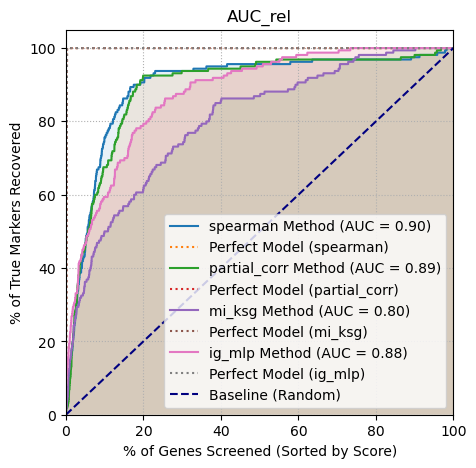

In [20]:
results = [
    results_spearman,
    results_partial_correlation,
    results_mi_ksg,
    results_ig_mlp
]

driver_recovery_metric.plot(results,
                            config.METHODS,
                            driver_gene_ground_truth)

## 3. Interpretation
Gene enrichment and annotation. Make a conclusion.